In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [49]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
# Visualization style
sns.set(style="whitegrid")

In [51]:
file_path = "/content/drive/MyDrive/Data mining Lab/Projrct/dhaka_air_quality_2000_2025.csv"
df = pd.read_csv(file_path)

df.head()

,datetime,AQI,PM2.5,PM10,O3,NO2,SO2,CO,Temperature,Humidity,Wind_Speed,Pressure
0,2000-01-01 00:00:00,121.861086,44.200712,93.224101,20.586862,15.391414,28.219932,1.049477,20.956667,71.272569,8.375675,1011.742574
1,2000-01-01 01:00:00,99.598077,35.212704,78.893066,22.429471,26.824534,24.385188,0.943859,13.761031,42.616871,10.880553,1010.949986
2,2000-01-01 02:00:00,132.852834,48.575428,118.693959,37.838094,33.403493,28.951413,0.887131,20.216907,59.169387,15.041183,1012.065387
3,2000-01-01 03:00:00,154.588259,64.208516,86.427166,26.747684,12.137395,26.950990,0.793261,18.642574,62.756439,9.904413,1010.162227
4,2000-01-01 04:00:00,114.102260,41.112699,70.193382,33.192759,25.313206,20.741976,1.059887,18.834718,56.369280,14.632070,1007.067421


# **Data** **Preprocessing**

In [23]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225816 entries, 0 to 225815
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   datetime     225816 non-null  object 
 1   AQI          225816 non-null  float64
 2   PM2.5        225816 non-null  float64
 3   PM10         225816 non-null  float64
 4   O3           225816 non-null  float64
 5   NO2          225816 non-null  float64
 6   SO2          225816 non-null  float64
 7   CO           225816 non-null  float64
 8   Temperature  225816 non-null  float64
 9   Humidity     225816 non-null  float64
 10  Wind_Speed   225816 non-null  float64
 11  Pressure     225816 non-null  float64
dtypes: float64(11), object(1)
memory usage: 20.7+ MB
None


In [24]:
print("\nStatistical Summary:")
display(df.describe())


Statistical Summary:


,AQI,PM2.5,PM10,O3,NO2,SO2,CO,Temperature,Humidity,Wind_Speed,Pressure
count,225816.000000,225816.000000,225816.000000,225816.000000,225816.000000,225816.000000,225816.000000,225816.000000,225816.000000,225816.000000,225816.000000
mean,173.879455,105.495390,178.668865,50.070796,34.295663,23.082057,1.644556,26.042161,70.020460,12.998380,1012.958425
std,47.853187,55.878730,95.030366,18.186844,12.189406,7.695508,0.535873,5.142185,10.623508,4.937334,7.866261
min,20.833333,5.000000,10.000000,5.000000,5.000000,2.000000,0.100000,10.345658,30.000000,8.000005,990.000000
25%,153.495856,62.135134,105.427706,37.130329,25.622285,17.721737,1.256414,22.084894,62.332422,9.447585,1007.622862
50%,171.495329,96.298134,164.382639,48.391279,33.784039,22.485259,1.612679,26.067808,69.341643,11.473965,1012.991058
75%,194.740957,140.418337,240.081570,61.145886,42.605845,27.792577,2.012451,29.997338,77.493987,14.940992,1018.406142
max,299.599600,250.000000,400.000000,124.493286,87.302685,57.272041,3.764566,40.000000,95.000000,40.000000,1030.000000


In [57]:
# Convert datetime column to datetime type
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

In [58]:
df.duplicated().sum()

np.int64(0)

In [59]:
# Extract time-based features
df['Year'] = df['datetime'].dt.year
df['Month'] = df['datetime'].dt.month
df['Day'] = df['datetime'].dt.day
df['Hour'] = df['datetime'].dt.hour

In [60]:
df.head()

,datetime,AQI,PM2.5,PM10,O3,NO2,SO2,CO,Temperature,Humidity,Wind_Speed,Pressure,Year,Month,Day,Hour
0,2000-01-01 00:00:00,121.861086,44.200712,93.224101,20.586862,15.391414,28.219932,1.049477,20.956667,71.272569,8.375675,1011.742574,2000,1,1,0
1,2000-01-01 01:00:00,99.598077,35.212704,78.893066,22.429471,26.824534,24.385188,0.943859,13.761031,42.616871,10.880553,1010.949986,2000,1,1,1
2,2000-01-01 02:00:00,132.852834,48.575428,118.693959,37.838094,33.403493,28.951413,0.887131,20.216907,59.169387,15.041183,1012.065387,2000,1,1,2
3,2000-01-01 03:00:00,154.588259,64.208516,86.427166,26.747684,12.137395,26.950990,0.793261,18.642574,62.756439,9.904413,1010.162227,2000,1,1,3
4,2000-01-01 04:00:00,114.102260,41.112699,70.193382,33.192759,25.313206,20.741976,1.059887,18.834718,56.369280,14.632070,1007.067421,2000,1,1,4


In [61]:
df.tail()

,datetime,AQI,PM2.5,PM10,O3,NO2,SO2,CO,Temperature,Humidity,Wind_Speed,Pressure,Year,Month,Day,Hour
225811,2025-10-04 19:00:00,207.114725,157.607611,243.872762,46.377704,38.243954,26.807971,1.243414,28.259699,62.551322,11.818046,1012.764603,2025,10,4,19
225812,2025-10-04 20:00:00,206.927397,157.420470,243.006506,39.320982,40.727546,35.334455,1.648275,24.709986,55.136078,8.800161,1017.514260,2025,10,4,20
225813,2025-10-04 21:00:00,191.182348,133.664097,222.090884,47.043134,29.740886,31.693231,1.516578,23.832922,68.360762,13.813644,1020.041276,2025,10,4,21
225814,2025-10-04 22:00:00,176.907248,106.569957,169.771198,41.824699,24.414738,28.654861,1.890719,23.119236,68.842075,11.024805,1015.671335,2025,10,4,22
225815,2025-10-04 23:00:00,187.985824,127.597094,230.334810,38.649642,32.247229,22.446088,1.949910,19.342047,60.956672,8.055435,1020.880531,2025,10,4,23


In [62]:
# Check missing values
print("\nMissing Values:")
display(df.isnull().sum())


Missing Values:


,0
datetime,0
AQI,0
PM2.5,0
PM10,0
O3,0
NO2,0
SO2,0
CO,0
Temperature,0
Humidity,0


In [63]:
# Remove duplicate rows (if any)
print("\nDuplicate rows before removal:", df.duplicated().sum())


Duplicate rows before removal: 0


In [64]:
# Feature selection
features = ['PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO', 'Temperature', 'Humidity', 'Wind_Speed', 'Pressure']
target = 'AQI'

In [65]:
X = df[features]
y = df[target]

In [66]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [67]:
print("\nScaled feature sample:")
print(X_scaled[:5])


Scaled feature sample:
[[-1.09692567 -0.89913316 -1.62117183 -1.55087876  0.66764737 -1.11048727
  -0.98897763  0.11786231 -0.93627748 -0.15456571]
 [-1.25777451 -1.04993829 -1.51985614 -0.61292122  0.1693369  -1.30758356
  -2.38831518 -2.57952914 -0.42894226 -0.25532381]
 [-1.01863604 -0.63111447 -0.67261418 -0.07319243  0.76270062 -1.41344347
  -1.13283904 -1.02142312  0.41374707 -0.11352788]
 [-0.73886729 -0.97065714 -1.28241952 -1.8178341   0.50275313 -1.58861562
  -1.43899991 -0.68377005 -0.62664862 -0.35546808]
 [-1.15218856 -1.14148485 -0.92803757 -0.73690849 -0.30408481 -1.09106088
  -1.40163358 -1.28500017  0.33088592 -0.74889676]]


# ==============================
# EDA Section
# ==============================

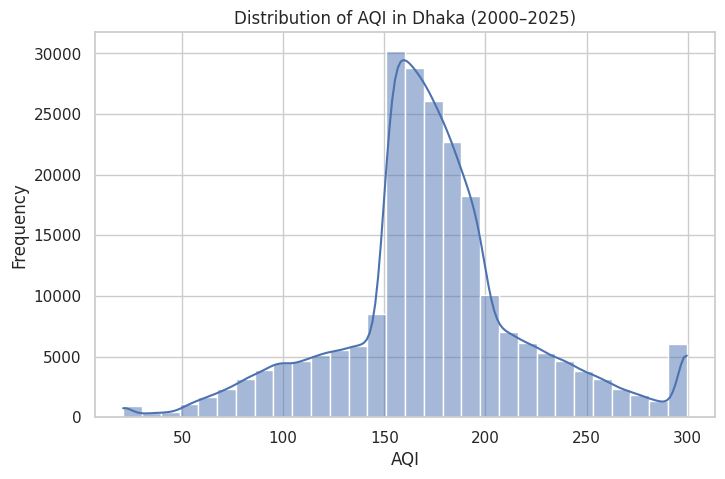

In [69]:
# AQI Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['AQI'], bins=30, kde=True)
plt.title("Distribution of AQI in Dhaka (2000–2025)")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

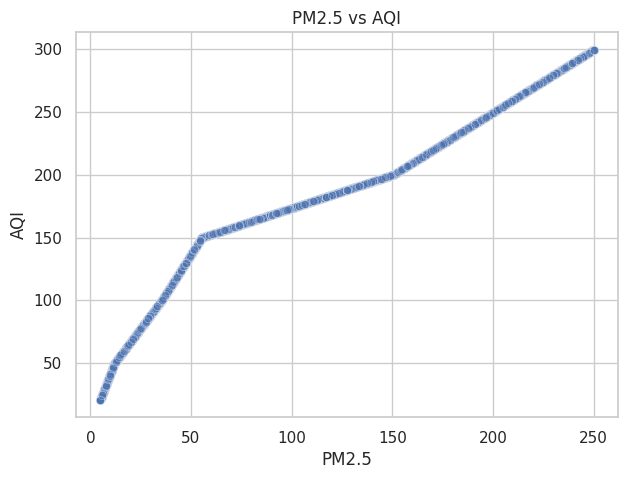

In [70]:
# PM2.5 vs AQI
plt.figure(figsize=(7,5))
sns.scatterplot(x='PM2.5', y='AQI', data=df, alpha=0.4)
plt.title("PM2.5 vs AQI")
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.show()

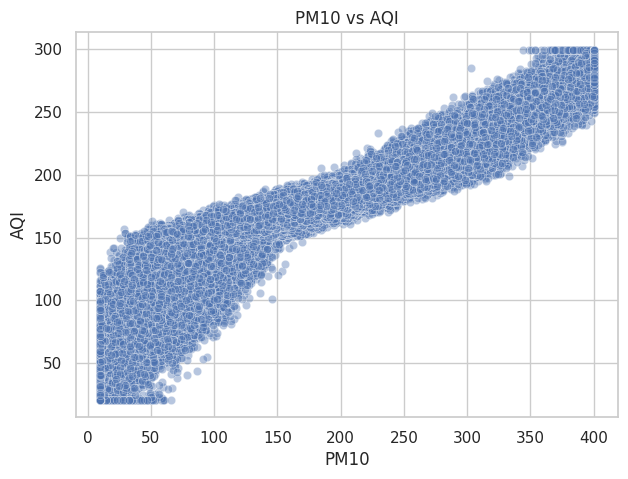

In [71]:
# PM10 vs AQI
plt.figure(figsize=(7,5))
sns.scatterplot(x='PM10', y='AQI', data=df, alpha=0.4)
plt.title("PM10 vs AQI")
plt.xlabel("PM10")
plt.ylabel("AQI")
plt.show()

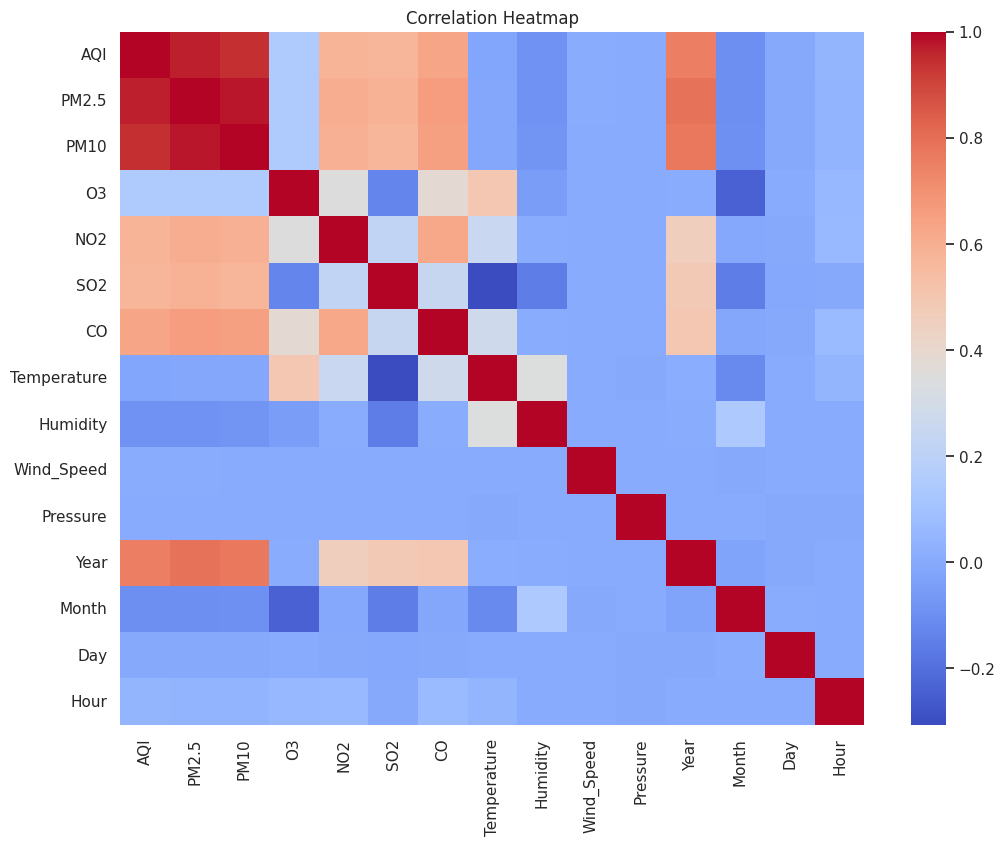

In [72]:
# Correlation Heatmap
plt.figure(figsize=(12,9))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [73]:
# Yearly AQI Trend
yearly_avg = df.groupby('Year')['AQI'].mean()

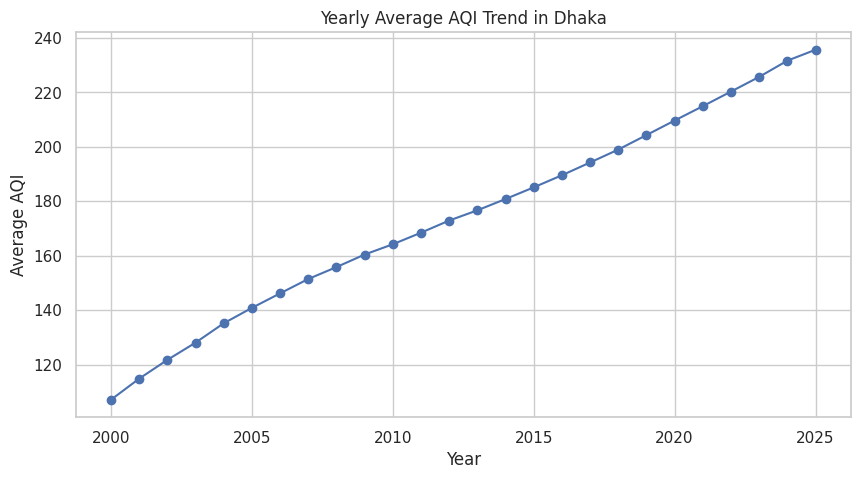

In [74]:
plt.figure(figsize=(10,5))
yearly_avg.plot(kind='line', marker='o')
plt.title("Yearly Average AQI Trend in Dhaka")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.grid(True)
plt.show()

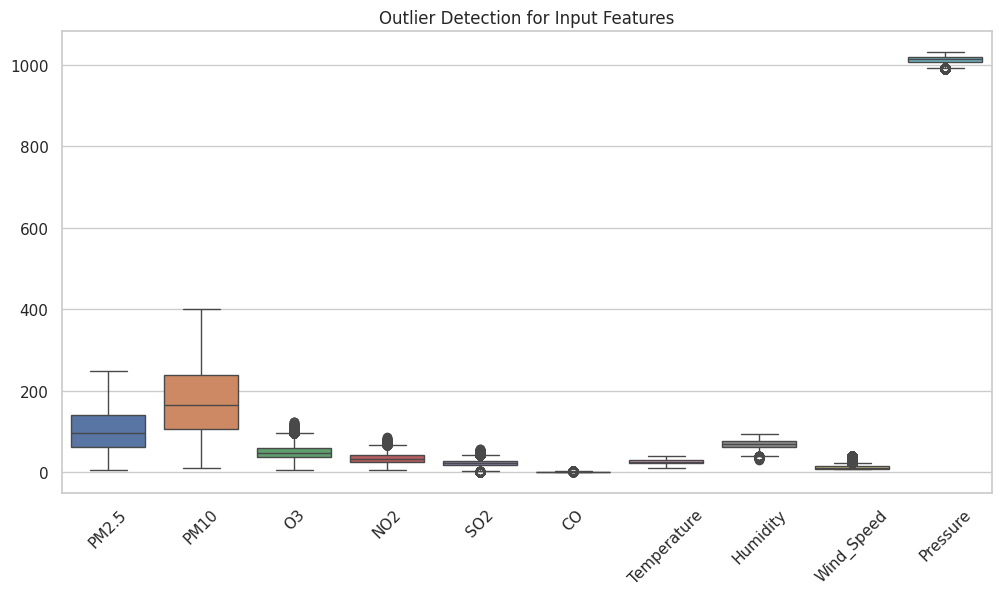

In [75]:
# Outlier Visualization (Boxplot)
plt.figure(figsize=(12,6))
sns.boxplot(data=df[features])
plt.title("Outlier Detection for Input Features")
plt.xticks(rotation=45)
plt.show()

In [76]:
print("\nPreprocessing and EDA Completed Successfully!")


Preprocessing and EDA Completed Successfully!
